# Прогнозирование времени до освобождения контейнера

## Описание задачи

На основании набора данных, где есть информация о том, сколько дней осталось до освобождения контейнера на целевой локации, необходимо построить прогнозную модель.

**Целевая переменная:** `days_until_free` - количество дней до освобождения контейнера

**Задача:** Регрессия - предсказание непрерывного значения времени до освобождения контейнера на основе признаков, характеризующих состояние контейнера и его перемещение.


## Импорт библиотек

Импортируем необходимые библиотеки для работы с данными.


In [1]:
import pandas as pd

import matplotlib.pyplot as plt 

## Установка зависимостей

Установка необходимых библиотек (выполнить при необходимости).


In [2]:
df_in = pd.read_csv('../data/cnt_events_transformed.csv')

df_in["dt"] = pd.to_datetime(df_in["dt"])


df_in


,dt,cnt_id,cycle_id,event,location_name,end_location_name,cnt_type,days_since_last_event,days_until_free
0,2006-01-02,STNU2517447,STNU2517447_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,0,28
1,2006-01-03,BUTU7001309,BUTU7001309_cycle_1,Передан_на_погрузку,Москва,Санкт-Петербург,20,0,24
2,2006-01-03,KNYU3537798,KNYU3537798_cycle_1,Передан_на_погрузку,Москва,Владивосток,20,0,40
3,2006-01-03,TOWU6899546,TOWU6899546_cycle_1,Передан_на_погрузку,Владивосток,Санкт-Петербург,20,0,43
4,2006-01-03,TOWU6899546,TOWU6899546_cycle_1,Прибыл_груженый,Владивосток,Санкт-Петербург,20,0,43
...,...,...,...,...,...,...,...,...,...
7135,2007-12-30,BUTU8729025,BUTU8729025_cycle_11,Отправлен_грузополучателю,Санкт-Петербург,Санкт-Петербург,40,1,1
7136,2007-12-30,BUTU9513169,BUTU9513169_cycle_14,Прибыл_свободным,Санкт-Петербург,Санкт-Петербург,40,7,0
7137,2007-12-30,ERKU4123975,ERKU4123975_cycle_12,Прибыл_свободным,Москва,Москва,40,2,0
7138,2007-12-31,BUTU8729025,BUTU8729025_cycle_11,Прибыл_свободным,Санкт-Петербург,Санкт-Петербург,40,1,0


## Загрузка данных

Загружаем исходный датасет с событиями контейнеров и преобразуем столбец с датами в формат datetime для удобной работы.


In [3]:
df_in.loc[lambda d: (d["cycle_id"]=="STNU2517447_cycle_3")]

,dt,cnt_id,cycle_id,event,location_name,end_location_name,cnt_type,days_since_last_event,days_until_free
725,2006-04-02,STNU2517447,STNU2517447_cycle_3,Передан_на_погрузку,Владивосток,Санкт-Петербург,40,0,35
793,2006-04-11,STNU2517447,STNU2517447_cycle_3,Прибыл_груженый,Владивосток,Санкт-Петербург,40,9,26
807,2006-04-12,STNU2517447,STNU2517447_cycle_3,Отправлен_по_ЖД,Владивосток,Санкт-Петербург,40,1,25
931,2006-04-25,STNU2517447,STNU2517447_cycle_3,Прибыл_по_ЖД,Санкт-Петербург,Санкт-Петербург,40,13,12
951,2006-04-27,STNU2517447,STNU2517447_cycle_3,Отправлен_грузополучателю,Санкт-Петербург,Санкт-Петербург,40,2,10
1058,2006-05-07,STNU2517447,STNU2517447_cycle_3,Прибыл_свободным,Санкт-Петербург,Санкт-Петербург,40,10,0


<Axes: xlabel='event', ylabel='days_until_free'>

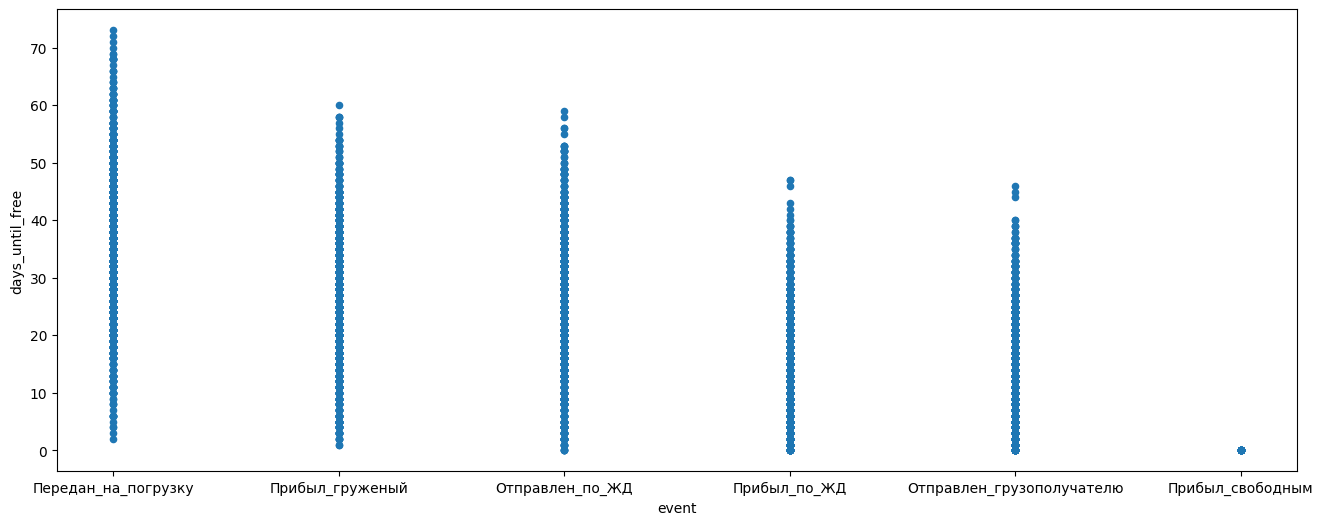

In [4]:
df_in.plot.scatter(x="event", y="days_until_free", figsize=(16, 6) )


<Axes: ylabel='Frequency'>

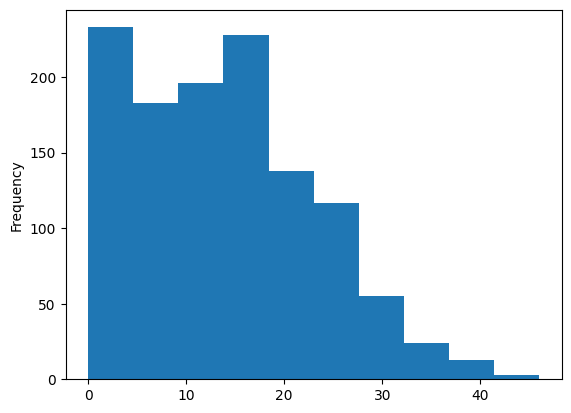

In [5]:
df_in.loc[lambda d: (d["event"]=="Отправлен_грузополучателю")].sort_values("days_until_free")["days_until_free"].plot.hist()

## Информация о данных

Просматриваем общую информацию о структуре датасета: количество строк, столбцов, типы данных и использование памяти.


In [6]:
df_in.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7140 entries, 0 to 7139
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   dt                     7140 non-null   datetime64[ns]
 1   cnt_id                 7140 non-null   object        
 2   cycle_id               7140 non-null   object        
 3   event                  7140 non-null   object        
 4   location_name          7140 non-null   object        
 5   end_location_name      7140 non-null   object        
 6   cnt_type               7140 non-null   int64         
 7   days_since_last_event  7140 non-null   int64         
 8   days_until_free        7140 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 502.2+ KB


## Кодирование локаций в координаты

Для использования информации о локациях в модели необходимо преобразовать названия городов в географические координаты (широта и долгота). Это позволит:
- Вычислить расстояние между начальной и конечной точкой маршрута
- Использовать пространственные признаки в модели

Используем библиотеку `geopy` для геокодирования и формулу Хаверсинуса для расчета расстояния между точками.

In [7]:
from geopy.geocoders import Nominatim
from functools import lru_cache
from math import radians, sin, cos, sqrt, atan2

geolocator = Nominatim(user_agent="container_geo")

@lru_cache(maxsize=128)
def geocode_city(city: str):
    location = geolocator.geocode(city + ", Россия")
    if location is None:
        return None, None
    return location.latitude, location.longitude


def haversine(lat1, lon1, lat2, lon2):
    # Радиус Земли в километрах
    R = 6371.0

    # Перевод градусов в радианы
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    # Разница координат
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Формула хаверсинуса
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

### Просмотр уникальных событий

Просматриваем все уникальные типы событий в датасете для создания корректного маппинга.


### Применение геокодирования

Применяем функции геокодирования к начальной и конечной локациям, а также вычисляем расстояние между ними в километрах.


### Пример жизненного цикла контейнера

Просматриваем пример полного жизненного цикла одного контейнера для понимания последовательности событий.


In [31]:
df = df_in.copy()

# для начальной локации
df[["loc_lat", "loc_lon"]] = df["location_name"] \
    .apply(lambda x: pd.Series(geocode_city(x)))

# для конечной локации
df[["end_lat", "end_lon"]] = df["end_location_name"] \
    .apply(lambda x: pd.Series(geocode_city(x)))

df["distance_km"] = df.apply(
    lambda row: haversine(row["loc_lat"], row["loc_lon"], row["end_lat"], row["end_lon"]),
    axis=1
)

df

,dt,cnt_id,cycle_id,event,location_name,end_location_name,cnt_type,days_since_last_event,days_until_free,loc_lat,loc_lon,end_lat,end_lon,distance_km
0,2006-01-02,STNU2517447,STNU2517447_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,0,28,43.115068,131.885577,55.625578,37.606392,6423.452790
1,2006-01-03,BUTU7001309,BUTU7001309_cycle_1,Передан_на_погрузку,Москва,Санкт-Петербург,20,0,24,55.625578,37.606392,59.960674,30.158655,652.834404
2,2006-01-03,KNYU3537798,KNYU3537798_cycle_1,Передан_на_погрузку,Москва,Владивосток,20,0,40,55.625578,37.606392,43.115068,131.885577,6423.452790
3,2006-01-03,TOWU6899546,TOWU6899546_cycle_1,Передан_на_погрузку,Владивосток,Санкт-Петербург,20,0,43,43.115068,131.885577,59.960674,30.158655,6542.987912
4,2006-01-03,TOWU6899546,TOWU6899546_cycle_1,Прибыл_груженый,Владивосток,Санкт-Петербург,20,0,43,43.115068,131.885577,59.960674,30.158655,6542.987912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7135,2007-12-30,BUTU8729025,BUTU8729025_cycle_11,Отправлен_грузополучателю,Санкт-Петербург,Санкт-Петербург,40,1,1,59.960674,30.158655,59.960674,30.158655,0.000000
7136,2007-12-30,BUTU9513169,BUTU9513169_cycle_14,Прибыл_свободным,Санкт-Петербург,Санкт-Петербург,40,7,0,59.960674,30.158655,59.960674,30.158655,0.000000
7137,2007-12-30,ERKU4123975,ERKU4123975_cycle_12,Прибыл_свободным,Москва,Москва,40,2,0,55.625578,37.606392,55.625578,37.606392,0.000000
7138,2007-12-31,BUTU8729025,BUTU8729025_cycle_11,Прибыл_свободным,Санкт-Петербург,Санкт-Петербург,40,1,0,59.960674,30.158655,59.960674,30.158655,0.000000


## Подготовка набора данных для модели

Выбираем признаки, которые будут использоваться для обучения модели. Исключаем текстовые столбцы и оставляем только числовые признаки:
- Координаты начальной и конечной локаций
- Расстояние между локациями
- Код события
- Количество дней с последнего события


## Кодирование событий

События в датасете представлены текстовыми значениями. Для использования в модели необходимо преобразовать их в числовые коды. Каждое событие в жизненном цикле контейнера получает уникальный числовой идентификатор.

### Просмотр уникальных событий

Просматриваем все уникальные типы событий в датасете для создания корректного маппинга.

### Пример жизненного цикла контейнера

Просматриваем пример полного жизненного цикла одного контейнера для понимания последовательности событий.

In [32]:
event_map = {
    "Передан_на_погрузку": 1,  
    "Прибыл_груженый": 2,
    "Отправлен_по_ЖД": 3, 
    "Прибыл_по_ЖД": 4, 
    "Отправлен_грузополучателю": 5,
    "Прибыл_свободным": 6
}

df["event_code"] = df["event"].map(event_map)


df

,dt,cnt_id,cycle_id,event,location_name,end_location_name,cnt_type,days_since_last_event,days_until_free,loc_lat,loc_lon,end_lat,end_lon,distance_km,event_code
0,2006-01-02,STNU2517447,STNU2517447_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,0,28,43.115068,131.885577,55.625578,37.606392,6423.452790,1
1,2006-01-03,BUTU7001309,BUTU7001309_cycle_1,Передан_на_погрузку,Москва,Санкт-Петербург,20,0,24,55.625578,37.606392,59.960674,30.158655,652.834404,1
2,2006-01-03,KNYU3537798,KNYU3537798_cycle_1,Передан_на_погрузку,Москва,Владивосток,20,0,40,55.625578,37.606392,43.115068,131.885577,6423.452790,1
3,2006-01-03,TOWU6899546,TOWU6899546_cycle_1,Передан_на_погрузку,Владивосток,Санкт-Петербург,20,0,43,43.115068,131.885577,59.960674,30.158655,6542.987912,1
4,2006-01-03,TOWU6899546,TOWU6899546_cycle_1,Прибыл_груженый,Владивосток,Санкт-Петербург,20,0,43,43.115068,131.885577,59.960674,30.158655,6542.987912,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7135,2007-12-30,BUTU8729025,BUTU8729025_cycle_11,Отправлен_грузополучателю,Санкт-Петербург,Санкт-Петербург,40,1,1,59.960674,30.158655,59.960674,30.158655,0.000000,5
7136,2007-12-30,BUTU9513169,BUTU9513169_cycle_14,Прибыл_свободным,Санкт-Петербург,Санкт-Петербург,40,7,0,59.960674,30.158655,59.960674,30.158655,0.000000,6
7137,2007-12-30,ERKU4123975,ERKU4123975_cycle_12,Прибыл_свободным,Москва,Москва,40,2,0,55.625578,37.606392,55.625578,37.606392,0.000000,6
7138,2007-12-31,BUTU8729025,BUTU8729025_cycle_11,Прибыл_свободным,Санкт-Петербург,Санкт-Петербург,40,1,0,59.960674,30.158655,59.960674,30.158655,0.000000,6


In [33]:
def expand_cycle_data(df):
    expanded_rows = []

    for cycle_id, group in df.groupby('cycle_id'):
        group = group.sort_values('dt')
        for i in range(len(group) - 1):
            current_row = group.iloc[i]
            next_row = group.iloc[i + 1]

            current_dt = current_row['dt']
            next_dt = next_row['dt']

            delta = next_dt - current_dt

            for day in range(1, delta.days):
                new_dt = current_dt + pd.Timedelta(days=day)
                new_row = current_row.copy()
                new_row['dt'] = new_dt
                new_row['days_since_last_event'] = day
                new_row['days_until_free'] = current_row['days_until_free'] - day
                expanded_rows.append(new_row)

    expanded_df = pd.concat([df, pd.DataFrame(expanded_rows)], ignore_index=True)
    expanded_df = expanded_df.sort_values(['cycle_id', 'dt'])

    return expanded_df

expand_cycle_data(df)

,dt,cnt_id,cycle_id,event,location_name,end_location_name,cnt_type,days_since_last_event,days_until_free,loc_lat,loc_lon,end_lat,end_lon,distance_km,event_code
129,2006-02-05,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,0,56,43.115068,131.885577,55.625578,37.606392,6423.45279,1
7140,2006-02-06,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,1,55,43.115068,131.885577,55.625578,37.606392,6423.45279,1
7141,2006-02-07,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,2,54,43.115068,131.885577,55.625578,37.606392,6423.45279,1
7142,2006-02-08,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,3,53,43.115068,131.885577,55.625578,37.606392,6423.45279,1
7143,2006-02-09,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,4,52,43.115068,131.885577,55.625578,37.606392,6423.45279,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44849,2007-07-11,WEDU9910122,WEDU9910122_cycle_9,Отправлен_грузополучателю,Санкт-Петербург,Санкт-Петербург,40,19,4,59.960674,30.158655,59.960674,30.158655,0.00000,5
44850,2007-07-12,WEDU9910122,WEDU9910122_cycle_9,Отправлен_грузополучателю,Санкт-Петербург,Санкт-Петербург,40,20,3,59.960674,30.158655,59.960674,30.158655,0.00000,5
44851,2007-07-13,WEDU9910122,WEDU9910122_cycle_9,Отправлен_грузополучателю,Санкт-Петербург,Санкт-Петербург,40,21,2,59.960674,30.158655,59.960674,30.158655,0.00000,5
44852,2007-07-14,WEDU9910122,WEDU9910122_cycle_9,Отправлен_грузополучателю,Санкт-Петербург,Санкт-Петербург,40,22,1,59.960674,30.158655,59.960674,30.158655,0.00000,5


In [35]:
df_model = df.copy()

# Добавляем пропущенные в данных дни
df_model = expand_cycle_data(df)

df_model = df_model[[
    "loc_lat",
    "loc_lon",
    "end_lat",
    "end_lon",
    "distance_km", 
    "days_since_last_event",  
    "days_until_free", 
    "event_code",
    # "event_Отправлен_грузополучателю",
    # "event_Отправлен_по_ЖД",	
    # "event_Передан_на_погрузку",	
    # "event_Прибыл_груженый",	
    # "event_Прибыл_по_ЖД",	
    # "event_Прибыл_свободным"
    ]]
df_model

,loc_lat,loc_lon,end_lat,end_lon,distance_km,days_since_last_event,days_until_free,event_code
129,43.115068,131.885577,55.625578,37.606392,6423.45279,0,56,1
7140,43.115068,131.885577,55.625578,37.606392,6423.45279,1,55,1
7141,43.115068,131.885577,55.625578,37.606392,6423.45279,2,54,1
7142,43.115068,131.885577,55.625578,37.606392,6423.45279,3,53,1
7143,43.115068,131.885577,55.625578,37.606392,6423.45279,4,52,1
...,...,...,...,...,...,...,...,...
44849,59.960674,30.158655,59.960674,30.158655,0.00000,19,4,5
44850,59.960674,30.158655,59.960674,30.158655,0.00000,20,3,5
44851,59.960674,30.158655,59.960674,30.158655,0.00000,21,2,5
44852,59.960674,30.158655,59.960674,30.158655,0.00000,22,1,5


## Обучение модели

Обучаем модель CatBoost для регрессии. CatBoost - это градиентный бустинг, который хорошо работает с категориальными признаками и не требует предварительной нормализации данных.

**Параметры модели:**
- `iterations=1000` - максимальное количество итераций
- `learning_rate=0.05` - скорость обучения
- `depth=6` - глубина деревьев
- `loss_function='RMSE'` - функция потерь (среднеквадратичная ошибка)

In [36]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
import numpy as np

# Сортировка данных
df_model = df_model.sort_index()

# Train / Test split (70 / 30)
split_idx = int(len(df_model) * 0.7)

train_data = df_model.iloc[:split_idx]
test_data = df_model.iloc[split_idx:]

X_train = train_data.drop(columns=['days_until_free'])
y_train = train_data['days_until_free']

X_test = test_data.drop(columns=['days_until_free'])
y_test = test_data['days_until_free']

# CatBoost Pools
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

# Optuna objective
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "loss_function": "RMSE",
        "random_state": 42,
        "verbose": 0
    }

    model = CatBoostRegressor(**params)

    model.fit(
        train_pool,
        eval_set=test_pool,
        early_stopping_rounds=50,
        verbose=False
    )

    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred)

    return rmse

# Запуск Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)

print("Best params:", study.best_params)
print("Best RMSE:", study.best_value)

# Обучение лучшей модели
best_model = CatBoostRegressor(
    **study.best_params,
    loss_function="RMSE",
    random_state=42,
    verbose=100
)

best_model.fit(train_pool, eval_set=test_pool)

# Оценка качества
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")


[I 2025-12-21 15:41:39,271] A new study created in memory with name: no-name-2a069990-d825-4c6a-8e27-638a0e7cbe62
[I 2025-12-21 15:41:39,554] Trial 0 finished with value: 83.66511506059781 and parameters: {'iterations': 772, 'learning_rate': 0.03887837175093404, 'depth': 10, 'l2_leaf_reg': 1.0343264071750715}. Best is trial 0 with value: 83.66511506059781.
[I 2025-12-21 15:41:40,009] Trial 1 finished with value: 83.67332097498476 and parameters: {'iterations': 676, 'learning_rate': 0.025623051162154336, 'depth': 10, 'l2_leaf_reg': 1.333141976571243}. Best is trial 0 with value: 83.66511506059781.
[I 2025-12-21 15:41:40,158] Trial 2 finished with value: 83.48794538553166 and parameters: {'iterations': 864, 'learning_rate': 0.08331961659330356, 'depth': 5, 'l2_leaf_reg': 3.4027950890057257}. Best is trial 2 with value: 83.48794538553166.
[I 2025-12-21 15:41:40,314] Trial 3 finished with value: 83.48149339592383 and parameters: {'iterations': 404, 'learning_rate': 0.07775648684966538, 'de

Best params: {'iterations': 477, 'learning_rate': 0.07398903510095954, 'depth': 4, 'l2_leaf_reg': 9.981432739783992}
Best RMSE: 83.40226030444894
0:	learn: 13.4463183	test: 13.3370174	best: 13.3370174 (0)	total: 1.79ms	remaining: 853ms
100:	learn: 9.0390903	test: 9.1343832	best: 9.1343832 (100)	total: 78.4ms	remaining: 292ms
200:	learn: 9.0102475	test: 9.1472126	best: 9.1324838 (122)	total: 149ms	remaining: 204ms
300:	learn: 8.9999490	test: 9.1606885	best: 9.1324838 (122)	total: 220ms	remaining: 128ms
400:	learn: 8.9954142	test: 9.1690207	best: 9.1324838 (122)	total: 287ms	remaining: 54.4ms
476:	learn: 8.9938710	test: 9.1720186	best: 9.1324838 (122)	total: 341ms	remaining: 0us

bestTest = 9.132483797
bestIteration = 122

Shrink model to first 123 iterations.
Mean Squared Error (MSE): 83.4023
Root Mean Squared Error (RMSE): 9.1325
Mean Absolute Error (MAE): 7.3139
R² Score: 0.5671


## Визуализация результатов модели

Создаем графики для анализа качества модели и понимания важности признаков.


### Важность признаков

График показывает, какие признаки наиболее важны для предсказания времени до освобождения контейнера.


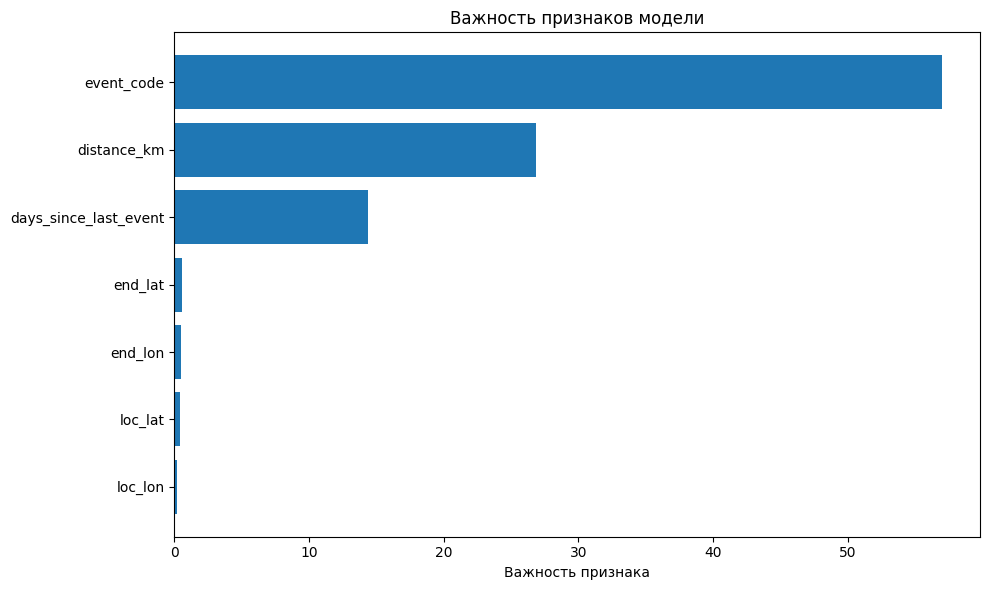


Важность признаков:
                 feature  importance
6             event_code   56.957067
4            distance_km   26.826706
5  days_since_last_event   14.412854
2                end_lat    0.592113
3                end_lon    0.504493
0                loc_lat    0.464533
1                loc_lon    0.242234


In [37]:
# Получаем важность признаков
feature_importance = best_model.get_feature_importance()
feature_names = X_train.columns

# Создаем DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Строим график
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Важность признака')
plt.title('Важность признаков модели')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nВажность признаков:")
print(importance_df)


### Сравнение предсказаний с реальными значениями

Scatter plot показывает, насколько хорошо модель предсказывает значения. Идеальная модель должна давать точки, расположенные вдоль диагональной линии y=x.


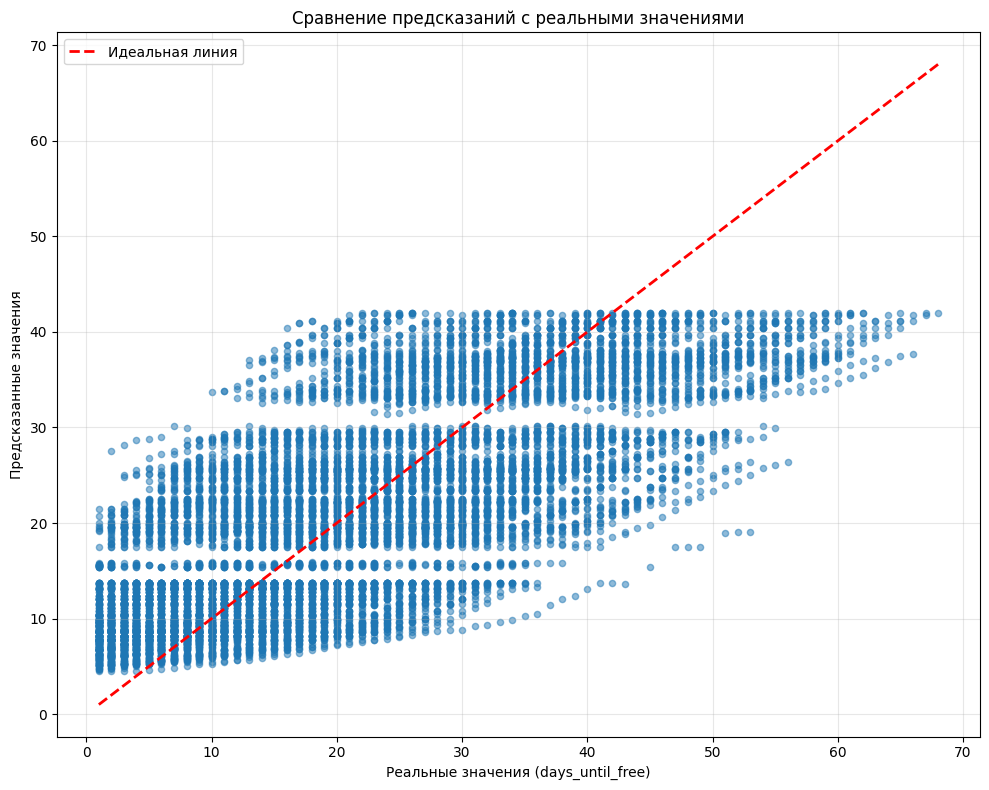

In [38]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.xlabel('Реальные значения (days_until_free)')
plt.ylabel('Предсказанные значения')
plt.title('Сравнение предсказаний с реальными значениями')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Средняя ошибка для разных значений целевой переменной

График показывает, как изменяется средняя абсолютная ошибка в зависимости от значения целевой переменной. Это помогает понять, на каких диапазонах значений модель работает лучше или хуже.


/tmp/ipykernel_161554/2700563562.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_error_by_bin = error_by_bin.groupby('bin')['error'].mean()


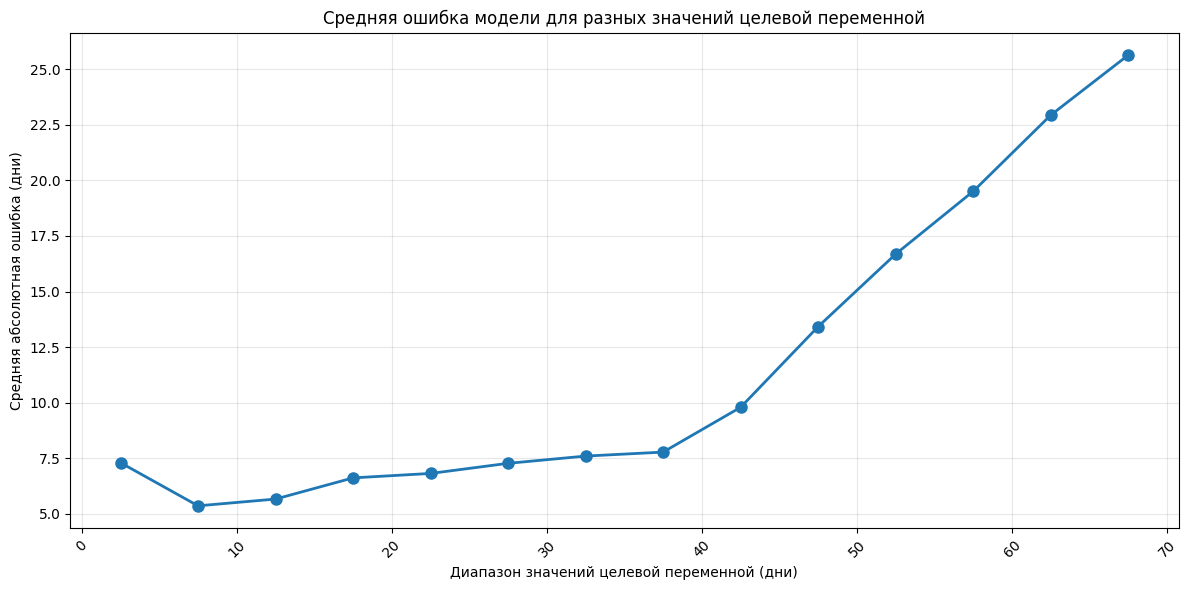


Средняя ошибка по диапазонам:
bin
0-5       7.304997
5-10      5.365541
10-15     5.669526
15-20     6.622395
20-25     6.821962
25-30     7.276718
30-35     7.602479
35-40     7.781536
40-45     9.796505
45-50    13.422369
50-55    16.685009
55-60    19.506517
60-65    22.931243
65-70    25.630704
Name: error, dtype: float64


In [39]:
# Вычисляем абсолютные ошибки
errors = np.abs(y_test - y_pred)

# Создаем бины для группировки по значениям целевой переменной
max_days = int(y_test.max())
bins = np.arange(0, max_days + 5, 5)  # Бин по 5 дней
bin_labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]

# Группируем ошибки по бинам
y_test_binned = pd.cut(y_test, bins=bins, labels=bin_labels, include_lowest=True)
error_by_bin = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'error': errors,
    'bin': y_test_binned
})

# Вычисляем среднюю ошибку для каждого бина
mean_error_by_bin = error_by_bin.groupby('bin')['error'].mean()
bin_centers = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]

# Строим график
plt.figure(figsize=(12, 6))
plt.plot(bin_centers, mean_error_by_bin.values, marker='o', linewidth=2, markersize=8)
plt.xlabel('Диапазон значений целевой переменной (дни)')
plt.ylabel('Средняя абсолютная ошибка (дни)')
plt.title('Средняя ошибка модели для разных значений целевой переменной')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nСредняя ошибка по диапазонам:")
print(mean_error_by_bin)


## Пайплайн прогнозирования для ручного ввода данных

Используйте функцию ниже для предсказания времени до освобождения контейнера на основе введенных параметров.


In [40]:
def predict_manual(event, location_name, end_location_name, days_since_last_event):
    """
    Функция для предсказания времени до освобождения контейнера на основе ручного ввода данных.
    
    Параметры:
    -----------
    event : str
        Тип события (например, "Прибыл_свободным", "Передан_на_погрузку", и т.д.)
    location_name : str
        Название начальной локации (например, "Москва", "Владивосток", "Санкт-Петербург")
    end_location_name : str
        Название конечной локации
    days_since_last_event : int
        Количество дней с последнего события
    
    Возвращает:
    -----------
    dict : Словарь с результатами предсказания
    """
    # Маппинг события в код
    event_map = {
        "Передан_на_погрузку": 1,  
        "Прибыл_груженый": 2,
        "Отправлен_по_ЖД": 3, 
        "Прибыл_по_ЖД": 4, 
        "Отправлен_грузополучателю": 5,
        "Прибыл_свободным": 6
    }
    
    # Проверка корректности события
    if event not in event_map:
        return {
            "error": f"Неизвестное событие: {event}",
            "available_events": list(event_map.keys())
        }
    
    event_code = event_map[event]
    
    # Геокодирование локаций
    loc_lat, loc_lon = geocode_city(location_name)
    end_lat, end_lon = geocode_city(end_location_name)
    
    if loc_lat is None or loc_lon is None:
        return {"error": f"Не удалось найти координаты для локации: {location_name}"}
    
    if end_lat is None or end_lon is None:
        return {"error": f"Не удалось найти координаты для конечной локации: {end_location_name}"}
    
    # Вычисление расстояния
    distance_km = haversine(loc_lat, loc_lon, end_lat, end_lon)
    
    # Формирование признаков для модели
    features = pd.DataFrame({
        'loc_lat': [loc_lat],
        'loc_lon': [loc_lon],
        'end_lat': [end_lat],
        'end_lon': [end_lon],
        'distance_km': [distance_km],
        'event_code': [event_code],
        'days_since_last_event': [days_since_last_event]
    })
    
    # Предсказание
    prediction = best_model.predict(features)[0]
    
    # Формирование результата
    result = {
        "Входные параметры": {
            "Событие": event,
            "Начальная локация": location_name,
            "Конечная локация": end_location_name,
            "Дней с последнего события": days_since_last_event
        },
        "Вычисленные признаки": {
            "Координаты начальной локации": f"({loc_lat:.6f}, {loc_lon:.6f})",
            "Координаты конечной локации": f"({end_lat:.6f}, {end_lon:.6f})",
            "Расстояние (км)": f"{distance_km:.2f}",
            "Код события": event_code
        },
        "Предсказание": {
            "Дней до освобождения контейнера": f"{prediction:.2f}"
        }
    }
    
    return result

# Пример использования:
print("Пример использования функции predict_manual:")
print("=" * 80)
result = predict_manual(
    event="Прибыл_свободным",
    location_name="Москва",
    end_location_name="Санкт-Петербург",
    days_since_last_event=5
)

if "error" in result:
    print(f"Ошибка: {result['error']}")
else:
    print("\nВходные параметры:")
    for key, value in result["Входные параметры"].items():
        print(f"  {key}: {value}")
    
    print("\nВычисленные признаки:")
    for key, value in result["Вычисленные признаки"].items():
        print(f"  {key}: {value}")
    
    print("\nПредсказание:")
    for key, value in result["Предсказание"].items():
        print(f"  {key}: {value} дней")


Пример использования функции predict_manual:

Входные параметры:
  Событие: Прибыл_свободным
  Начальная локация: Москва
  Конечная локация: Санкт-Петербург
  Дней с последнего события: 5

Вычисленные признаки:
  Координаты начальной локации: (55.625578, 37.606392)
  Координаты конечной локации: (59.960674, 30.158655)
  Расстояние (км): 652.83
  Код события: 6

Предсказание:
  Дней до освобождения контейнера: 3.73 дней


### Использование пайплайна

Для использования пайплайна вызовите функцию `predict_manual()` с нужными параметрами:

```python
result = predict_manual(
    event="Отправлен_грузополучателю",           # Тип события
    location_name="Москва",             # Начальная локация
    end_location_name="Москва", # Конечная локация
    days_since_last_event=5             # Дней с последнего события
)

# Результат содержит:
# - Входные параметры
# - Вычисленные признаки (координаты, расстояние)
# - Предсказание (дней до освобождения)
```

**Доступные события:**
- `"Передан_на_погрузку"`
- `"Прибыл_груженый"`
- `"Отправлен_по_ЖД"`
- `"Прибыл_по_ЖД"`
- `"Отправлен_грузополучателю"`
- `"Прибыл_свободным"`


In [42]:
predict_manual(
    event="Отправлен_грузополучателю",           # Тип события
    location_name="Москва",             # Начальная локация
    end_location_name="Москва", # Конечная локация
    days_since_last_event=3             # Дней с последнего события
)

{'Входные параметры': {'Событие': 'Отправлен_грузополучателю',
  'Начальная локация': 'Москва',
  'Конечная локация': 'Москва',
  'Дней с последнего события': 3},
 'Вычисленные признаки': {'Координаты начальной локации': '(55.625578, 37.606392)',
  'Координаты конечной локации': '(55.625578, 37.606392)',
  'Расстояние (км)': '0.00',
  'Код события': 5},
 'Предсказание': {'Дней до освобождения контейнера': '13.56'}}